# Processing AR cubes: umbra / penumbra / Qsun

For every downloaded region (`data/raw/NOAA_<noaa>_<date>/region_01_*_cube.fits`, produced by `01A_download_data.ipynb`), this notebook:
1. Segments each continuum frame into **umbra**, **penumbra**, and **Qsun** (everything that isn't umbra or penumbra).
2. Averages Qsun per frame and subtracts that value from the *whole* magnetogram/dopplergram frame, so Qsun's own mean becomes 0 and umbra/penumbra become quiet-sun-relative.
3. Plots the umbra/penumbra/both/Qsun magnetogram and dopplergram averages over time, same layout as `notebooks/03_data_analisis.ipynb`.

The new NOAA cubes don't have a dedicated quiet-sun patch cube (unlike `sebastian_sun_spots/DS*`, which `src/sunspot_analysis.py` is built around), so Qsun here is the mask complement instead — this notebook is self-contained rather than reusing that module.

**Note:** the two current `NOAA_11117_*` directories (2010-10-27 and 2010-10-28) are stale, mismatched-size leftovers from before the multi-day box-sizing fix in `01A`. They're processed as-is below like any other region — cleaning them up isn't this notebook's job.

In [1]:
import sys
import pathlib

project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from src.utilities import parse_frame_timestamp

DATA_DIR = pathlib.Path('../data/raw')
UMBRA_THRESH    = 30_000   # continuum DN — below this -> umbra
PENUMBRA_THRESH = 50_000   # continuum DN — below this (and not umbra) -> penumbra

## Discover regions

Any `NOAA_*` directory with a `region_01_continuum_cube.fits` — this naturally skips the pre-HMI ARs (11039, 11041), which have no cube files at all.

In [2]:
regions = []
for region_dir in sorted(DATA_DIR.glob('NOAA_*')):
    cont_cube = region_dir / 'region_01_continuum_cube.fits'
    if cont_cube.exists():
        regions.append(region_dir)

print(f'{len(regions)} region(s) found:')
for r in regions:
    print(' ', r.name)

5 region(s) found:
  NOAA_11106_2010-09-16
  NOAA_11117_2010-10-27
  NOAA_11117_2010-10-28
  NOAA_11363_2011-12-06
  NOAA_11536_2012-07-31


## Per-region processing

`process_region` loads the three cubes, aligns their frame counts (they're occasionally off by one — a boundary-rounding artifact of independently downloading each series — trimmed to the common minimum from the start), derives a real per-frame time axis from the still-on-disk per-file continuum FITS (cadence varies by AR — 720s normally, ~360s sampled for 11117 — so a fixed cadence assumption would be wrong), builds the umbra/penumbra/Qsun masks, zeroes out Qsun, and returns everything plotting needs.

In [3]:
def process_region(region_dir):
    cube_cont = fits.getdata(region_dir / 'region_01_continuum_cube.fits',   ext=0).astype(float)
    cube_mag  = fits.getdata(region_dir / 'region_01_magnetogram_cube.fits', ext=0).astype(float)
    cube_dop  = fits.getdata(region_dir / 'region_01_dopplergram_cube.fits', ext=0).astype(float)

    lengths = {'continuum': len(cube_cont), 'magnetogram': len(cube_mag), 'dopplergram': len(cube_dop)}
    n_t = min(lengths.values())
    if len(set(lengths.values())) > 1:
        print(f'  trimming {lengths} -> {n_t} frames')
    cube_cont, cube_mag, cube_dop = cube_cont[:n_t], cube_mag[:n_t], cube_dop[:n_t]

    # Real per-frame timestamps from the original per-file downloads (cadence varies by AR).
    frame_files = sorted((region_dir / 'region_01').glob('hmi.ic_*.continuum.fits'))
    timestamps = [parse_frame_timestamp(f) for f in frame_files[:n_t]]
    time_h = np.array([(t - timestamps[0]).total_seconds() / 3600 for t in timestamps])

    # Masks: umbra / penumbra from continuum thresholds, Qsun = everything else.
    umbra    = (cube_cont < UMBRA_THRESH) & np.isfinite(cube_cont)
    penumbra = (cube_cont < PENUMBRA_THRESH) & np.isfinite(cube_cont) & ~umbra
    both     = umbra | penumbra
    qsun     = ~both & np.isfinite(cube_cont)

    # Zero out Qsun: subtract its per-frame spatial mean from the *whole* frame.
    for t in range(n_t):
        mag_qsun_mean = np.nanmean(np.where(qsun[t], cube_mag[t], np.nan))
        dop_qsun_mean = np.nanmean(np.where(qsun[t], cube_dop[t], np.nan))
        cube_mag[t] = cube_mag[t] - mag_qsun_mean
        cube_dop[t] = cube_dop[t] - dop_qsun_mean

    def region_means(cube, mask):
        return np.array([np.nanmean(cube[t][mask[t]]) if mask[t].any() else np.nan for t in range(n_t)])

    means = {
        'mag': {name: region_means(cube_mag, mask) for name, mask in
                [('Umbra', umbra), ('Penumbra', penumbra), ('Both', both), ('Quiet Sun', qsun)]},
        'dop': {name: region_means(cube_dop, mask) for name, mask in
                [('Umbra', umbra), ('Penumbra', penumbra), ('Both', both), ('Quiet Sun', qsun)]},
    }
    return time_h, means

In [4]:
COLORS = {'Umbra': 'red', 'Penumbra': 'blue', 'Both': 'purple', 'Quiet Sun': 'black'}

def plot_time_series(region_dir, time_h, means):
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

    for name, series in means['mag'].items():
        ax1.plot(time_h, series, color=COLORS[name], lw=0.8, label=name)
    ax1.set_ylabel('Mean B − quiet sun  (G)')
    ax1.set_title(f'{region_dir.name} — mean magnetogram')
    ax1.grid(alpha=0.3)
    ax1.legend()

    for name, series in means['dop'].items():
        ax2.plot(time_h, series, color=COLORS[name], lw=0.8, label=name)
    ax2.set_ylabel('Mean velocity − quiet sun  (m/s)')
    ax2.set_xlabel('Time  (h)')
    ax2.set_title(f'{region_dir.name} — mean dopplergram')
    ax2.grid(alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

NOAA_11106_2010-09-16


  trimming {'continuum': 60, 'magnetogram': 61, 'dopplergram': 61} -> 60 frames


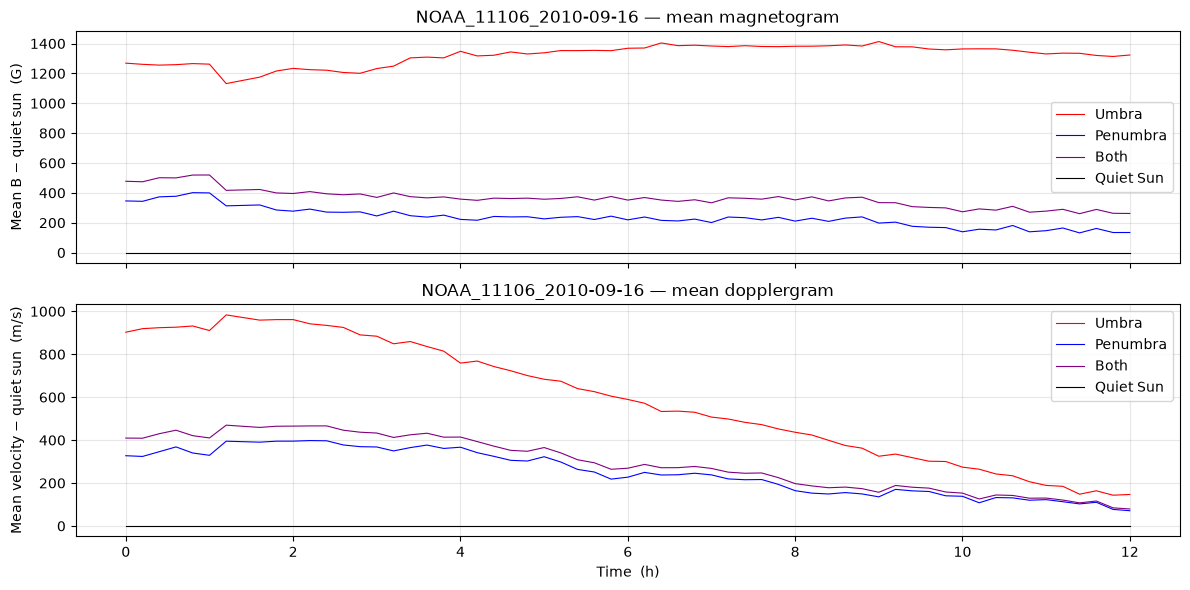

NOAA_11117_2010-10-27


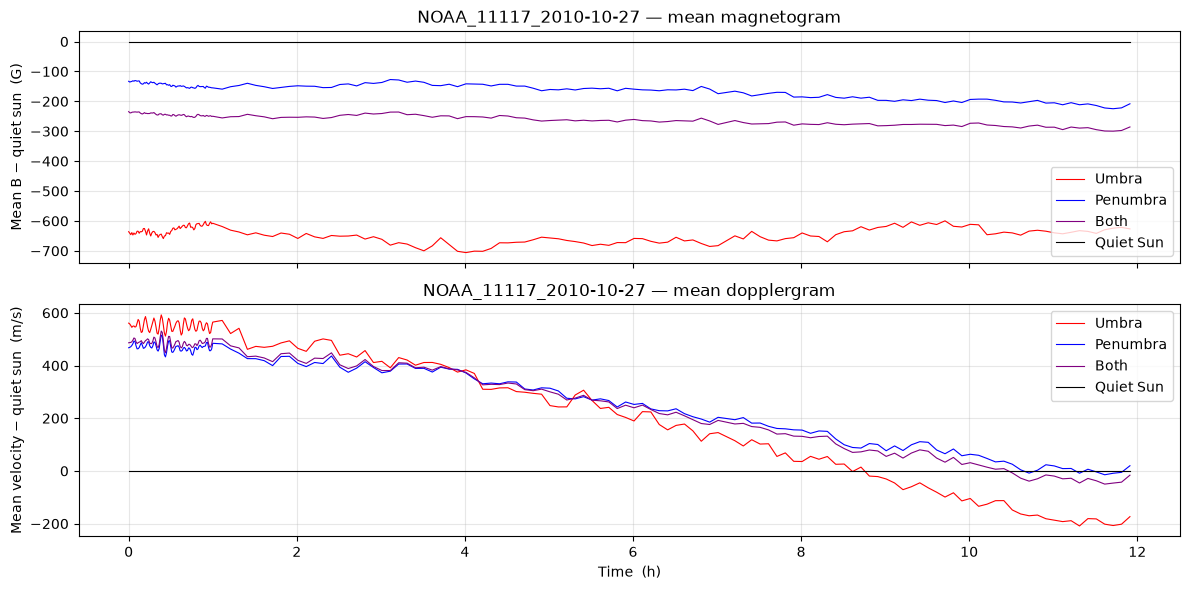

NOAA_11117_2010-10-28


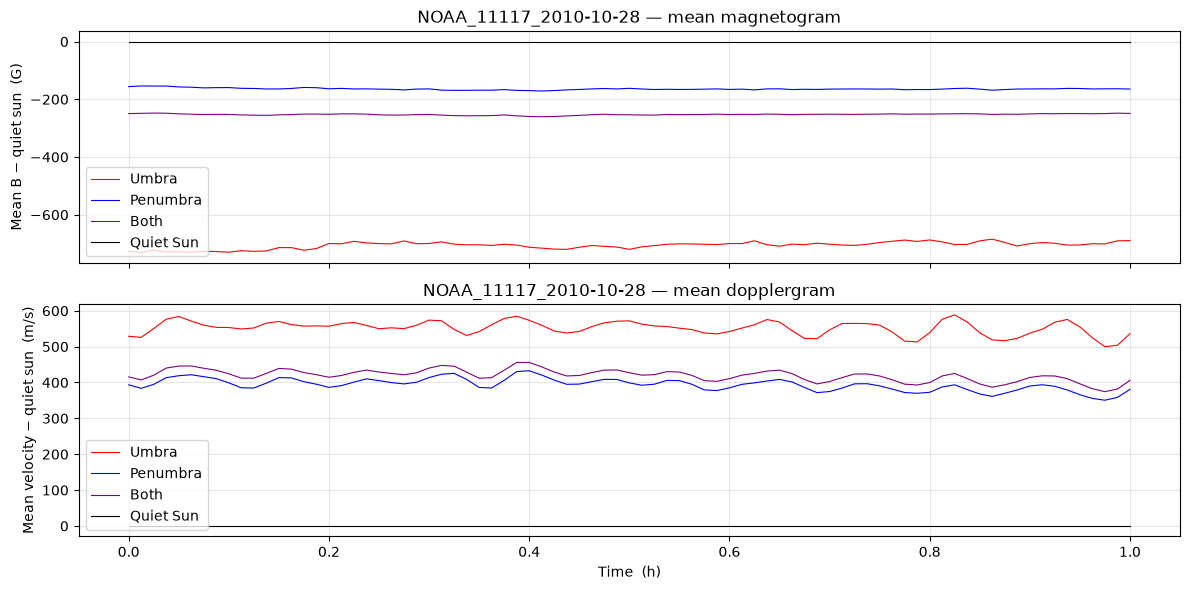

NOAA_11363_2011-12-06
  trimming {'continuum': 61, 'magnetogram': 60, 'dopplergram': 61} -> 60 frames


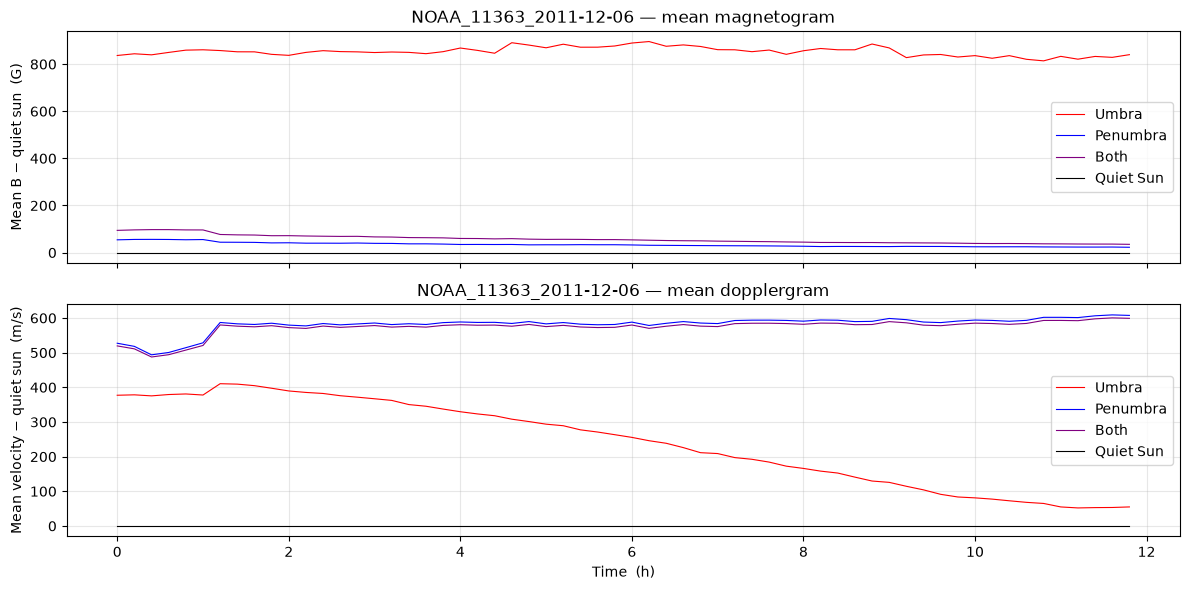

NOAA_11536_2012-07-31
  trimming {'continuum': 61, 'magnetogram': 61, 'dopplergram': 60} -> 60 frames


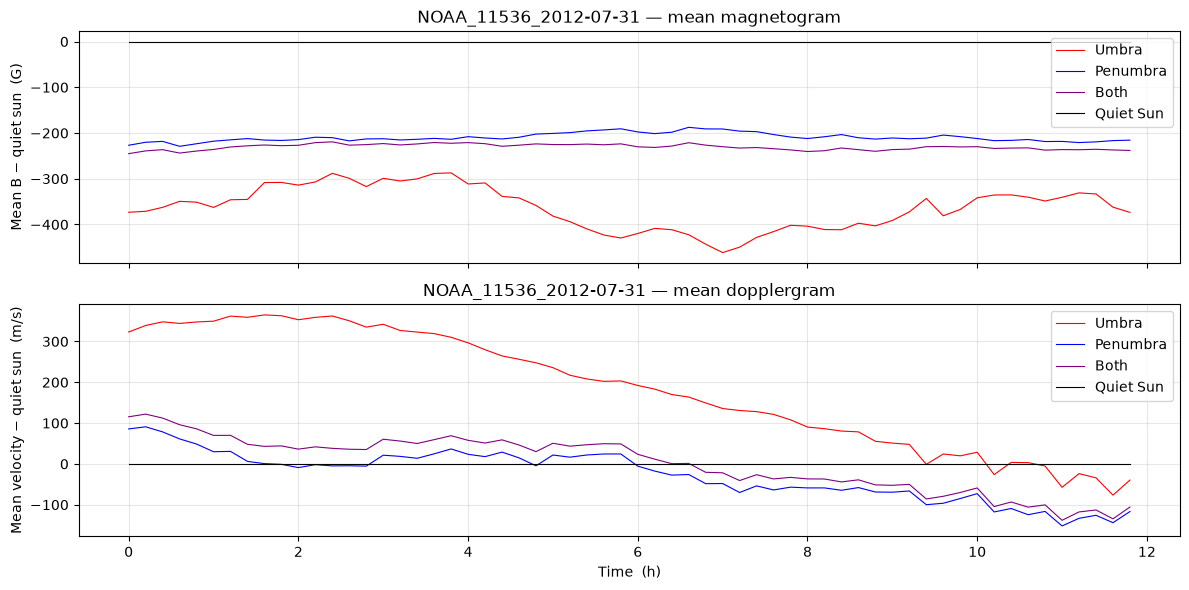

In [5]:
for region_dir in regions:
    print(region_dir.name)
    time_h, means = process_region(region_dir)
    plot_time_series(region_dir, time_h, means)